<a href="https://colab.research.google.com/github/chandkhush/self-pruning-network/blob/main/Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-Pruning Neural Network

This project implements a self-pruning neural network using learnable gates and sparsity regularization.

In [2]:
!pip install torch torchvision matplotlib

In [5]:
import torch
import torchvision
import matplotlib

print("Setup Complete")

Setup Complete


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Imports done ")

Imports done 


In [71]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # normal weights
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2)

    def forward(self, x):
        # convert scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # apply pruning
        pruned_weights = self.weight * gates

        # normal linear operation
        return F.linear(x, pruned_weights, self.bias)

In [72]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        # flatten image
        x = x.view(x.size(0), -1)

        # layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [73]:
model = Net()
print(model)

Net(
  (fc1): PrunableLinear()
  (fc2): PrunableLinear()
  (fc3): PrunableLinear()
)


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# convert images to tensor
transform = transforms.ToTensor()

# training data
train_data = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# testing data
test_data = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# create loaders
from torch.utils.data import Subset

train_subset = Subset(train_data, range(5000))
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

print("Dataset loaded ")

100%|██████████| 170M/170M [00:05<00:00, 29.4MB/s]


Dataset loaded 


In [8]:
criterion = nn.CrossEntropyLoss()

In [76]:
def sparsity_loss(model):
    loss = 0
    total = 0

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = torch.sigmoid(layer.gate_scores)

            loss += gates.sum()
            total += gates.numel()

    return loss / total

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # normal weights
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2)

    def forward(self, x):
        # convert scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)

        # apply pruning
        pruned_weights = self.weight * gates

        # normal linear operation
        return F.linear(x, pruned_weights, self.bias)

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        # flatten image
        x = x.view(x.size(0), -1)

        # layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

def sparsity_loss(model):
    loss = 0
    total = 0

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = torch.sigmoid(layer.gate_scores)

            loss += gates.sum()
            total += gates.numel()

    return loss / total

model = Net()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lambda_ = 0.001

epochs = 10

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for images, labels in train_loader:

        # forward pass
        outputs = model(images)

        # losses
        ce_loss = criterion(outputs, labels)
        sp_loss = sparsity_loss(model)

        loss = ce_loss + lambda_ * sp_loss

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 91.3048
Epoch 2, Loss: 85.8865
Epoch 3, Loss: 83.2311
Epoch 4, Loss: 82.5333
Epoch 5, Loss: 81.1517
Epoch 6, Loss: 80.0961
Epoch 7, Loss: 79.8423
Epoch 8, Loss: 78.4191
Epoch 9, Loss: 78.5892
Epoch 10, Loss: 77.2924


In [14]:
def test(model):
    model.eval()   # evaluation mode

    correct = 0
    total = 0

    with torch.no_grad():   # no gradient needed
        for images, labels in test_loader:

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [15]:
acc = test(model)
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 27.82%


In [16]:
def calculate_sparsity(model, threshold=0.1):
    total = 0
    pruned = 0

    for layer in model.modules():
        if isinstance(layer, PrunableLinear):

            gates = torch.sigmoid(layer.gate_scores)

            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    sparsity = 100 * pruned / total
    return sparsity

In [17]:
sp = calculate_sparsity(model)
print(f"Sparsity: {sp:.2f}%")

Sparsity: 41.99%


In [18]:

lambda_values = [0.1, 0.5, 1.0]
results = []

for lam in lambda_values:
    print(f"\nTraining with lambda = {lam}")

    model = Net()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # train
    for epoch in range(3):
        model.train()

        for images, labels in train_loader:

            outputs = model(images)

            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lam * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # evaluate
    acc = test(model)
    sp = calculate_sparsity(model)

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sp:.2f}%")

    results.append((lam, acc, sp))


Training with lambda = 0.1
Accuracy: 19.12%, Sparsity: 43.19%

Training with lambda = 0.5
Accuracy: 19.19%, Sparsity: 44.67%

Training with lambda = 1.0
Accuracy: 18.63%, Sparsity: 45.41%


In [19]:
for r in results:
    print(f"Lambda: {r[0]}, Accuracy: {r[1]:.2f}%, Sparsity: {r[2]:.2f}%")

Lambda: 0.1, Accuracy: 19.12%, Sparsity: 43.19%
Lambda: 0.5, Accuracy: 19.19%, Sparsity: 44.67%
Lambda: 1.0, Accuracy: 18.63%, Sparsity: 45.41%


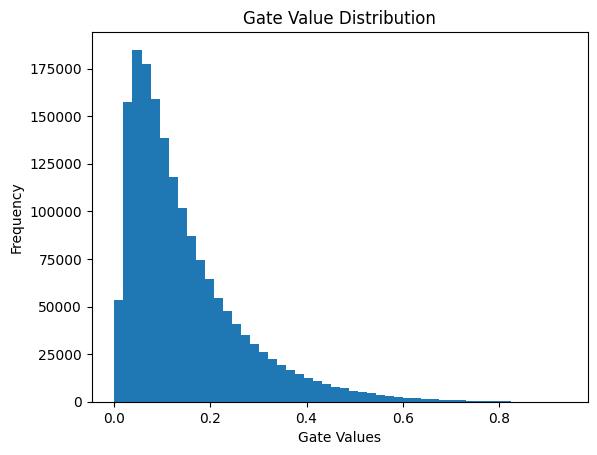

In [20]:
import matplotlib.pyplot as plt

all_gates = []

for layer in model.modules():
    if isinstance(layer, PrunableLinear):
        gates = torch.sigmoid(layer.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()

In [21]:
for lam, acc, sp in results:
    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sp:.2f}%")

Lambda: 0.1, Accuracy: 19.12%, Sparsity: 43.19%
Lambda: 0.5, Accuracy: 19.19%, Sparsity: 44.67%
Lambda: 1.0, Accuracy: 18.63%, Sparsity: 45.41%


In [86]:
torch.save(model.state_dict(), "pruned_model.pth")

In [22]:
print("\nFinal Results:\n")
print("Lambda\tAccuracy\tSparsity")

for lam, acc, sp in results:
    print(f"{lam}\t{acc:.2f}%\t\t{sp:.2f}%")


Final Results:

Lambda	Accuracy	Sparsity
0.1	19.12%		43.19%
0.5	19.19%		44.67%
1.0	18.63%		45.41%
